<a href="https://colab.research.google.com/github/edtallison/interp-notebooks/blob/main/activation_patching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformer_lens

import transformer_lens
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("distilgpt2")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.7 MB/s eta 0:00:00


/tmp/ipykernel_663/2254235008.py:6: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained("distilgpt2")


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model distilgpt2 into HookedTransformer


In [ ]:
clean_prompt = "The capital of France is"
corrupted_prompt = "The capital of Japan is"

clean_tokens = model.to_tokens(clean_prompt)
corrupted_tokens = model.to_tokens(corrupted_prompt)

clean_logits, clean_cache = model.run_with_cache(clean_tokens)
corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

In [ ]:
paris_token = model.to_single_token(" Paris")
tokyo_token = model.to_single_token(" Tokyo")

def logit_diff(logits):
    final_logits = logits[0, -1, :]  # last token position
    return final_logits[paris_token] - final_logits[tokyo_token]

clean_diff = logit_diff(clean_logits)      # should be strongly positive
corrupted_diff = logit_diff(corrupted_logits)  # should be strongly negative

In [ ]:
def patch_resid_hook(activation, hook, position, clean_cache):
    activation[:, position, :] = clean_cache[hook.name][:, position, :]
    return activation

In [ ]:
import torch

n_layers = model.cfg.n_layers
seq_len = corrupted_tokens.shape[1]
results = torch.zeros(n_layers, seq_len)

for layer in range(n_layers):
    for position in range(seq_len):
        hook_name = f"blocks.{layer}.hook_resid_post"

        def hook_fn(activation, hook, position=position):
            return patch_resid_hook(activation, hook, position, clean_cache)

        patched_logits = model.run_with_hooks(
            corrupted_tokens,
            fwd_hooks=[(hook_name, hook_fn)]
        )
        results[layer, position] = logit_diff(patched_logits)

Text(0.5, 1.0, 'Activation patching: resid_post')

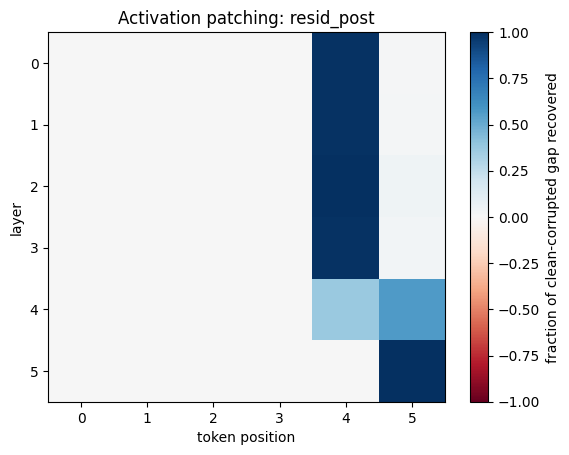

In [ ]:
import matplotlib.pyplot as plt

# normalize: 0 = corrupted baseline, 1 = clean baseline
normalized = (results - corrupted_diff) / (clean_diff - corrupted_diff)

plt.imshow(normalized.detach().numpy(), aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
plt.xlabel("token position")
plt.ylabel("layer")
plt.colorbar(label="fraction of clean-corrupted gap recovered")
plt.title("Activation patching: resid_post")

In [ ]:
last_logits = clean_logits[0, -1, :]  # shape: (vocab_size,)
predicted_token_id = last_logits.argmax()
predicted_token = model.to_string(predicted_token_id)
print(predicted_token)  # e.g. " Paris"

 the


In [ ]:
import torch

probs = torch.softmax(last_logits, dim=-1)
top_probs, top_tokens = torch.topk(probs, k=5)

for prob, tok in zip(top_probs, top_tokens):
    print(f"{model.to_string(tok):>10} : {prob.item():.3f}")

       the : 0.075
      home : 0.066
         a : 0.048
       now : 0.042
     being : 0.038


In [ ]:
paris_token = model.to_single_token(" Paris")
tokyo_token = model.to_single_token(" Tokyo")

print("P(Paris):", probs[paris_token].item())
print("P(Tokyo):", probs[tokyo_token].item())

P(Paris): 0.0005752515862695873
P(Tokyo): 2.646434586495161e-05


In [ ]:
output_text = model.generate(clean_prompt, max_new_tokens=10, temperature=0)
print(output_text)

  0%|          | 0/10 [00:00<?, ?it/s]

The capital of France is the capital of the French Republic. The capital of


In [ ]:
paris_token = model.to_single_token(" Paris")
paris_prob = probs[paris_token].item()
paris_rank = (probs > probs[paris_token]).sum().item()
print(f"Paris: prob={paris_prob:.4f}, rank={paris_rank}")

Paris: prob=0.0006, rank=200


In [ ]:
gpt2_model = HookedTransformer.from_pretrained("gpt2")
gpt2_logits = gpt2_model(clean_tokens)
# rerun the top-k check

/tmp/ipykernel_663/2043464654.py:1: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  gpt2_model = HookedTransformer.from_pretrained("gpt2")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer


In [ ]:
last_logits = gpt2_logits[0, -1, :]  # shape: (vocab_size,)
predicted_token_id = last_logits.argmax()
predicted_token = model.to_string(predicted_token_id)
print(predicted_token)  # e.g. " Paris"

 now


In [ ]:
import torch

probs = torch.softmax(last_logits, dim=-1)
top_probs, top_tokens = torch.topk(probs, k=5)

for prob, tok in zip(top_probs, top_tokens):
    print(f"{model.to_string(tok):>10} : {prob.item():.3f}")

       now : 0.048
       the : 0.037
         a : 0.035
      home : 0.031
        in : 0.027


In [ ]:
paris_token = model.to_single_token(" Paris")
paris_prob = probs[paris_token].item()
paris_rank = (probs > probs[paris_token]).sum().item()
print(f"Paris: prob={paris_prob:.4f}, rank={paris_rank}")

Paris: prob=0.0016, rank=92
